# Setup

In [1]:
# ─────────────────────────────────────────────
# 03_baseline_rag.ipynb
#
# Purpose:
#   Evaluate three baseline pipelines:
#     1. No-RAG  — cross-encoder, no retrieval
#     2. RAG     — FAISS retrieval + CE scoring
#     3. Compare both and establish baseline numbers
#
# Inputs (from Notebooks 01-02):
#   data/cleaned_kb_docs.pkl
#   data/kb_index_cleaned.faiss
#   data/index_config.pkl
#   data/bm25_index.pkl
#   data/val_eval_mcq.pkl
#
# Outputs:
#   results/no_rag_baseline.json
#   results/rag_baseline.json
#   results/baseline_comparison.json
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers rank-bm25 -q

import os
import sys
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, ensure_dirs,
    CLEANED_KB_PATH, FAISS_INDEX_PATH,
    INDEX_CONFIG_PATH, VAL_EVAL_MCQ_PATH,
    CE_BASE_MODEL,
)
from src.data_processing import load_pkl
from src.knowledge_base import load_faiss_index, load_bm25_index
from src.models import load_retriever, load_cross_encoder
from src.mcq_pipeline import no_rag_pipeline, rag_pipeline
from src.evaluation import (
    evaluate_pipeline, build_ablation_table,
    print_ablation_table, save_results,
    compute_faithfulness, compute_ece,
    analyse_failure_types,
)

ensure_dirs()

BM25_INDEX_PATH  = f"{DATA_DIR}/bm25_index.pkl"
NO_RAG_PATH      = f"{RESULTS_DIR}/no_rag_baseline.json"
RAG_BASELINE_PATH= f"{RESULTS_DIR}/rag_baseline.json"
BASELINE_CMP_PATH= f"{RESULTS_DIR}/baseline_comparison.json"

print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.4 MB/s eta 0:00:00
Mounted at /content/drive
Setup complete


#  Load all artifacts

In [2]:
# ─────────────────────────────────────────────
# Load all required artifacts from Drive
# Everything must exist from previous notebooks
# ─────────────────────────────────────────────

# Data
cleaned_kb_docs = load_pkl(CLEANED_KB_PATH,  "cleaned_kb_docs")
val_eval_mcq    = load_pkl(VAL_EVAL_MCQ_PATH, "val_eval_mcq")

# Build id lookup for metrics later
kb_id_lookup = {i: doc
                 for i, doc in enumerate(cleaned_kb_docs)}
kb_id_by_docid = {doc['id']: (i, doc)
                   for i, doc in enumerate(cleaned_kb_docs)}

# Index
faiss_index, index_config = load_faiss_index()
bm25_index                = load_bm25_index(BM25_INDEX_PATH)

# Models
retriever     = load_retriever()
cross_encoder = load_cross_encoder(CE_BASE_MODEL)

print(f"\nAll artifacts loaded:")
print(f"  KB docs:      {len(cleaned_kb_docs):,}")
print(f"  Val eval MCQ: {len(val_eval_mcq):,}")
print(f"  FAISS index:  {faiss_index.ntotal:,} vectors")
print(f"  nprobe:       {faiss_index.nprobe}")
print(f"  CE model:     {CE_BASE_MODEL}")

  Loaded cleaned_kb_docs
  Loaded val_eval_mcq
FAISS index loaded:
  Vectors: 156,555
  nprobe:  50
  Trained: True
  BM25 index loaded: 290,428 terms
Loading retriever: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

  Max length: 512 tokens

All artifacts loaded:
  KB docs:      156,555
  Val eval MCQ: 2,092
  FAISS index:  156,555 vectors
  nprobe:       50
  CE model:     cross-encoder/ms-marco-MiniLM-L-6-v2


# Pipeline 1: No-RAG baseline

In [3]:
# ─────────────────────────────────────────────
# Pipeline 1 — No-RAG
#
# Cross-encoder scores each option against
# empty context string.
# Measures: model prior knowledge only
# Expected accuracy: ~28-30%
# ─────────────────────────────────────────────

if os.path.exists(NO_RAG_PATH):
    print("No-RAG results already exist — loading\n")
    with open(NO_RAG_PATH) as f:
        no_rag_data = json.load(f)
    no_rag_acc = no_rag_data['accuracy']
    no_rag_results = no_rag_data['results']
    print(f"No-RAG accuracy: {no_rag_acc:.2f}%")

else:
    print("Running No-RAG evaluation...\n")

    no_rag_eval = evaluate_pipeline(
        val_eval_mcq,
        lambda q, opts: no_rag_pipeline(
            q, opts, cross_encoder),
        desc="No-RAG baseline",
    )

    no_rag_acc     = no_rag_eval['accuracy']
    no_rag_results = no_rag_eval['results']

    # Additional metrics
    faithfulness = compute_faithfulness(no_rag_results)
    ece          = compute_ece(no_rag_results)

    no_rag_data = {
        "system":          "no_rag",
        "model":           CE_BASE_MODEL,
        "accuracy":        no_rag_acc,
        "correct":         no_rag_eval['correct'],
        "total":           no_rag_eval['total'],
        "faithfulness":    faithfulness,
        "ece":             ece['ece'],
        "subject_accuracy":no_rag_eval['subject_accuracy'],
        "retrieval_counts":no_rag_eval['retrieval_counts'],
        "results":         no_rag_results,
    }

    save_results(no_rag_data, NO_RAG_PATH, "no_rag_baseline")
    print(f"\nNo-RAG accuracy: {no_rag_acc:.2f}%")
    print(f"Random chance:   25.00%")
    print(f"Gain over random: +{no_rag_acc-25:.2f}%")

Running No-RAG evaluation...



No-RAG baseline: 100%|██████████| 2092/2092 [00:20<00:00, 102.60it/s]


  Saved no_rag_baseline: 1000.0 KB

No-RAG accuracy: 28.97%
Random chance:   25.00%
Gain over random: +3.97%


#  Pipeline 2: RAG baseline

In [4]:
# ─────────────────────────────────────────────
# Pipeline 2 — RAG baseline
#
# FAISS dense retrieval (top-5 passages)
# + cross-encoder option scoring on top passage
# No CRAG correction — blind trust in retrieval
#
# Expected accuracy: ~35-37%
# ─────────────────────────────────────────────

if os.path.exists(RAG_BASELINE_PATH):
    print("RAG baseline results already exist — loading\n")
    with open(RAG_BASELINE_PATH) as f:
        rag_data = json.load(f)
    rag_acc     = rag_data['accuracy']
    rag_results = rag_data['results']
    print(f"RAG baseline accuracy: {rag_acc:.2f}%")

else:
    print("Running RAG baseline evaluation...\n")

    rag_eval = evaluate_pipeline(
        val_eval_mcq,
        lambda q, opts: rag_pipeline(
            q, opts, faiss_index,
            cleaned_kb_docs, retriever,
            cross_encoder),
        desc="RAG baseline",
    )

    rag_acc     = rag_eval['accuracy']
    rag_results = rag_eval['results']

    # Additional metrics
    faithfulness = compute_faithfulness(rag_results)
    ece          = compute_ece(rag_results)
    failure_types= analyse_failure_types(
        rag_results, kb_id_by_docid)

    rag_data = {
        "system":          "rag_baseline",
        "model":           CE_BASE_MODEL,
        "accuracy":        rag_acc,
        "correct":         rag_eval['correct'],
        "total":           rag_eval['total'],
        "faithfulness":    faithfulness,
        "ece":             ece['ece'],
        "ece_bins":        ece['bin_data'],
        "failure_types":   failure_types,
        "subject_accuracy":rag_eval['subject_accuracy'],
        "retrieval_counts":rag_eval['retrieval_counts'],
        "results":         rag_results,
    }

    save_results(rag_data, RAG_BASELINE_PATH, "rag_baseline")
    print(f"\nRAG baseline accuracy: {rag_acc:.2f}%")
    print(f"No-RAG accuracy:       {no_rag_acc:.2f}%")
    print(f"RAG gain:              +{rag_acc-no_rag_acc:.2f}%")

Running RAG baseline evaluation...



RAG baseline: 100%|██████████| 2092/2092 [00:53<00:00, 39.22it/s]


  Saved rag_baseline: 1314.9 KB

RAG baseline accuracy: 35.42%
No-RAG accuracy:       28.97%
RAG gain:              +6.45%


#  Failure type analysis

RAG BASELINE — FAILURE TYPE ANALYSIS

Total errors: 1,351
  (out of 2,092 questions)

Type       Description                          Count    Frac  CRAG fix?
--------------------------------------------------------------------------------
Type 1     Wrong document retrieved               653  48.3%  CRAG gate + BM25 fallback
Type 2     Right doc, wrong option selected       698  51.7%  Reranking (partial fix)
Type 3     Knowledge gap — no relevant doc          0   0.0%  Not fixable without KB expansion
Type 4     Elimination / hard reasoning             0   0.0%  Encoder architecture limitation


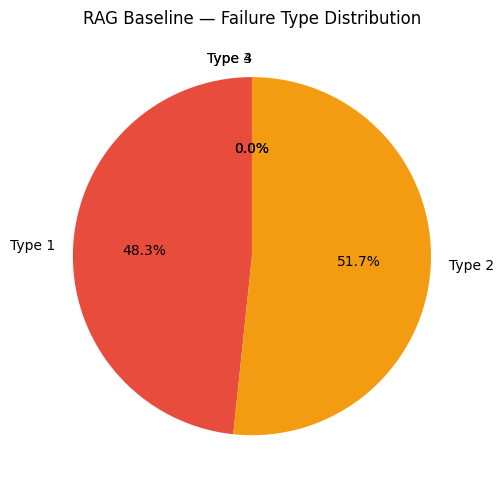

In [5]:
# ─────────────────────────────────────────────
# Analyse RAG baseline failure types
# This informs which CRAG components
# will have the most impact in Notebook 04
# ─────────────────────────────────────────────

ft = rag_data.get('failure_types') or \
     analyse_failure_types(rag_results, kb_id_by_docid)

print("RAG BASELINE — FAILURE TYPE ANALYSIS\n")
print(f"Total errors: {ft['total_errors']:,}")
print(f"  (out of {len(val_eval_mcq):,} questions)\n")

types = [
    ("Type 1", "Wrong document retrieved",
     ft['type1_count'], ft['type1_fraction'],
     "CRAG gate + BM25 fallback"),
    ("Type 2", "Right doc, wrong option selected",
     ft['type2_count'], ft['type2_fraction'],
     "Reranking (partial fix)"),
    ("Type 3", "Knowledge gap — no relevant doc",
     ft['type3_count'], ft['type3_fraction'],
     "Not fixable without KB expansion"),
    ("Type 4", "Elimination / hard reasoning",
     ft['type4_count'], ft['type4_fraction'],
     "Encoder architecture limitation"),
]

print(f"{'Type':<10} {'Description':<35} "
      f"{'Count':>6} {'Frac':>7}  {'CRAG fix?'}")
print("-" * 80)
for label, desc, count, frac, fix in types:
    print(f"{label:<10} {desc:<35} "
          f"{count:>6,} {frac:>6.1%}  {fix}")

# Pie chart
labels  = [f"Type {i+1}" for i in range(4)]
sizes   = [ft['type1_fraction'], ft['type2_fraction'],
            ft['type3_fraction'], ft['type4_fraction']]
colors  = ['#E74C3C','#F39C12','#9B59B6','#3498DB']

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title("RAG Baseline — Failure Type Distribution")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/failure_type_distribution.png",
            dpi=150)
plt.show()

#  Faithfulness and ECE analysis

In [6]:
# ─────────────────────────────────────────────
# Faithfulness:
#   Does the predicted option text appear
#   in the retrieved passage?
#   High faithfulness = answers grounded in context
#
# ECE:
#   Does confidence score predict accuracy?
#   Low ECE = well-calibrated confidence
# ─────────────────────────────────────────────

print("ADDITIONAL METRICS — RAG BASELINE\n")

# Faithfulness
faith = rag_data.get('faithfulness') or \
        compute_faithfulness(rag_results)
print("Faithfulness (answer in retrieved passage):")
print(f"  Overall:   {faith['overall_faithfulness']:.3f}")
print(f"  Correct:   {faith['correct_faithfulness']:.3f}")
print(f"  Incorrect: {faith['incorrect_faithfulness']:.3f}")
print(f"  n:         {faith['n_evaluated']:,}")

# ECE
ece_result = rag_data.get('ece_bins') and \
             {'ece': rag_data['ece'],
              'bin_data': rag_data['ece_bins']} or \
             compute_ece(rag_results)

if isinstance(ece_result, dict) and 'ece' in ece_result:
    ece_val  = ece_result['ece']
    bin_data = ece_result.get('bin_data', [])
else:
    ece_val  = rag_data.get('ece', 0)
    bin_data = rag_data.get('ece_bins', [])

print(f"\nExpected Calibration Error (ECE):")
print(f"  ECE: {ece_val:.4f}")
print(f"  (0 = perfect calibration, "
      f"1 = completely miscalibrated)")
print(f"\n  {'Bin':<15} {'Count':>6} "
      f"{'Accuracy':>9} {'Confidence':>11} {'Gap':>6}")
print("  " + "-" * 52)
for b in bin_data:
    if b:
        print(f"  {b['bin']:<15} {b['count']:>6,} "
              f"{b['accuracy']:>9.3f} "
              f"{b['confidence']:>11.3f} "
              f"{b['gap']:>6.3f}")

ADDITIONAL METRICS — RAG BASELINE

Faithfulness (answer in retrieved passage):
  Overall:   0.137
  Correct:   0.244
  Incorrect: 0.078
  n:         2,092

Expected Calibration Error (ECE):
  ECE: 0.1314
  (0 = perfect calibration, 1 = completely miscalibrated)

  Bin              Count  Accuracy  Confidence    Gap
  ----------------------------------------------------
  [0.2,0.3)          360     0.297       0.280  0.017
  [0.3,0.4)          656     0.280       0.346  0.065
  [0.4,0.5)          361     0.377       0.447  0.071
  [0.5,0.6)          228     0.364       0.548  0.184
  [0.6,0.7)          128     0.383       0.646  0.263
  [0.7,0.8)          124     0.444       0.749  0.305
  [0.8,0.9)           98     0.531       0.846  0.315
  [0.9,1.0)          137     0.547       0.956  0.409


#  Per-subject breakdown

PER-SUBJECT ACCURACY — RAG BASELINE

Subject                                Acc% Bar
------------------------------------------------------------
Ophthalmology                         57.7%  ███████████
Psychiatry                            57.1%  ███████████
Forensic Medicine                     48.1%  █████████
Orthopaedics                          45.5%  █████████
Physiology                            42.7%  ████████
Pharmacology                          39.8%  ███████
Biochemistry                          39.4%  ███████
Anatomy                               39.3%  ███████
Gynaecology & Obstetrics              38.5%  ███████
Radiology                             37.9%  ███████
Pediatrics                            37.7%  ███████
ENT                                   37.5%  ███████
Pathology                             35.7%  ███████
Surgery                               34.0%  ██████
Medicine                              33.5%  ██████
Skin                                  33.3%  ███

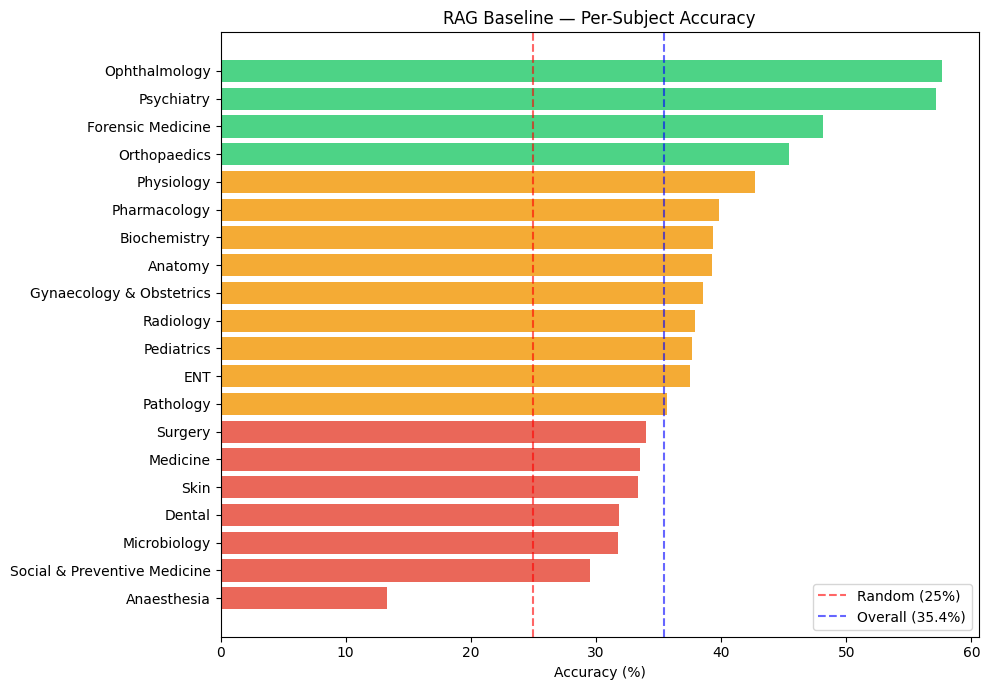

In [7]:
# ─────────────────────────────────────────────
# Per-subject accuracy for RAG baseline
# Identifies which subjects have weak retrieval
# These are candidates for most improvement in CRAG
# ─────────────────────────────────────────────

subj_acc = rag_data['subject_accuracy']

print("PER-SUBJECT ACCURACY — RAG BASELINE\n")
print(f"{'Subject':<35} {'Acc%':>7} {'Bar'}")
print("-" * 60)

sorted_subj = sorted(subj_acc.items(),
                      key=lambda x: x[1], reverse=True)
for subj, acc in sorted_subj:
    if subj == "Unknown":
        continue
    bar   = "█" * int(acc / 5)
    flag  = " ← WEAK" if acc < 30 else ""
    print(f"{subj:<35} {acc:>6.1f}%  {bar}{flag}")

print(f"\nOverall: {rag_acc:.2f}%")

# Chart
subjects = [s for s, _ in sorted_subj if s != "Unknown"]
accs     = [a for s, a in sorted_subj if s != "Unknown"]
colors   = ['#2ECC71' if a >= 45 else
             '#F39C12' if a >= 35 else
             '#E74C3C' for a in accs]

plt.figure(figsize=(10, 7))
plt.barh(subjects[::-1], accs[::-1],
         color=colors[::-1], alpha=0.85)
plt.axvline(25, color='red', ls='--',
            alpha=0.6, label='Random (25%)')
plt.axvline(rag_acc, color='blue', ls='--',
            alpha=0.6, label=f'Overall ({rag_acc:.1f}%)')
plt.xlabel("Accuracy (%)")
plt.title("RAG Baseline — Per-Subject Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/rag_subject_accuracy.png",
            dpi=150)
plt.show()

# Baseline comparison summary

In [8]:
# ─────────────────────────────────────────────
# Build comparison table and save JSON
# This JSON feeds into the final metrics notebook
# ─────────────────────────────────────────────

comparison = {
    "random_chance": {
        "accuracy": 25.0,
        "description": "4-option random selection"
    },
    "no_rag": {
        "accuracy":    no_rag_acc,
        "description": "Cross-encoder, no retrieval",
        "model":       CE_BASE_MODEL,
        "ece":         no_rag_data.get('ece', None),
        "faithfulness":no_rag_data.get(
            'faithfulness', {}).get(
            'overall_faithfulness', None),
    },
    "rag_baseline": {
        "accuracy":      rag_acc,
        "description":   "FAISS retrieval + CE scoring",
        "model":         CE_BASE_MODEL,
        "rag_gain":      round(rag_acc - no_rag_acc, 2),
        "ece":           rag_data.get('ece', None),
        "faithfulness":  rag_data.get(
            'faithfulness', {}).get(
            'overall_faithfulness', None),
        "failure_types": {
            "type1_pct": round(
                ft['type1_fraction'] * 100, 1),
            "type2_pct": round(
                ft['type2_fraction'] * 100, 1),
            "type3_pct": round(
                ft['type3_fraction'] * 100, 1),
            "type4_pct": round(
                ft['type4_fraction'] * 100, 1),
        }
    }
}

save_results(comparison, BASELINE_CMP_PATH,
             "baseline_comparison")

# Print summary table
print("\n" + "="*55)
print("BASELINE SUMMARY")
print("="*55)
print(f"  Random chance:    25.00%")
print(f"  No-RAG:           {no_rag_acc:.2f}%  "
      f"(+{no_rag_acc-25:.2f}% over random)")
print(f"  RAG baseline:     {rag_acc:.2f}%  "
      f"(+{rag_acc-no_rag_acc:.2f}% over no-RAG)")
print(f"\nFailure type breakdown:")
print(f"  Type 1 (wrong doc):   "
      f"{ft['type1_fraction']*100:.1f}%")
print(f"  Type 2 (wrong option):"
      f"{ft['type2_fraction']*100:.1f}%")
print(f"  Type 3 (no doc):      "
      f"{ft['type3_fraction']*100:.1f}%")
print(f"  Type 4 (elimination): "
      f"{ft['type4_fraction']*100:.1f}%")
print("="*55)

  Saved baseline_comparison: 0.7 KB

BASELINE SUMMARY
  Random chance:    25.00%
  No-RAG:           28.97%  (+3.97% over random)
  RAG baseline:     35.42%  (+6.45% over no-RAG)

Failure type breakdown:
  Type 1 (wrong doc):   48.3%
  Type 2 (wrong option):51.7%
  Type 3 (no doc):      0.0%
  Type 4 (elimination): 0.0%


# Final verification

In [9]:
# ─────────────────────────────────────────────
# Verify all Notebook 03 outputs
# ─────────────────────────────────────────────

print("NOTEBOOK 03 — FINAL VERIFICATION\n")

checks = [
    (NO_RAG_PATH,       "no_rag_baseline.json",    True),
    (RAG_BASELINE_PATH, "rag_baseline.json",        True),
    (BASELINE_CMP_PATH, "baseline_comparison.json", True),
    (f"{RESULTS_DIR}/failure_type_distribution.png",
     "failure_type_distribution.png", True),
    (f"{RESULTS_DIR}/rag_subject_accuracy.png",
     "rag_subject_accuracy.png", True),
]

all_ok = True
for path, label, required in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    status = "✅" if exists else "❌"
    if not exists and required:
        all_ok = False
    print(f"  {status} {label:<40} {size:>8.1f} KB")

print(f"\nKey numbers:")
print(f"  Random chance:  25.00%")
print(f"  No-RAG:         {no_rag_acc:.2f}%")
print(f"  RAG baseline:   {rag_acc:.2f}%")

print()
if all_ok:
    print("All checks passed ✅")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 03 — FINAL VERIFICATION

  ✅ no_rag_baseline.json                       1000.0 KB
  ✅ rag_baseline.json                          1314.9 KB
  ✅ baseline_comparison.json                      0.7 KB
  ✅ failure_type_distribution.png                36.6 KB
  ✅ rag_subject_accuracy.png                     94.0 KB

Key numbers:
  Random chance:  25.00%
  No-RAG:         28.97%
  RAG baseline:   35.42%

All checks passed ✅
